# Apply Codec Macroblock Perturbations

```{warning}
`CodecMacroblockPerturber` is an experimental feature. Its API and behavior may change in future releases. The perturber must be enabled using `import nrtk.experimental`.
```

This notebook shows how to apply the {py:class}`~nrtk.impls.perturb_video.CodecMacroblockPerturber` to a short video. The perturber encodes the frame sequence with a real codec, decodes it again, and returns the decoded frames. That round trip introduces compression artifacts such as blockiness and loss of fine detail.

## Set Up the Environment

```{note}
Warnings are suppressed to keep the notebook output focused. If something goes wrong while running the notebook, rerun without the first code cell so the warnings are visible.
```

In [1]:
from __future__ import annotations

import warnings

warnings.filterwarnings("ignore")

```{important}
This notebook requires NRTK with the following extra:

- `pyav`: PyAV bindings for FFmpeg codec support

The next cell will install this extra. See [Installation](<project:/getting_started/installation.rst>) for installation alternatives.
```

In [2]:
%pip install -qU pip
print("Installing nrtk with required extras...")
%pip install -q "nrtk[pyav]"
print("Installing notebook-specific packages...")
%pip install -q matplotlib

Note: you may need to restart the kernel to use updated packages.
Installing nrtk with required extras...


Note: you may need to restart the kernel to use updated packages.


Installing notebook-specific packages...


Note: you may need to restart the kernel to use updated packages.


```{note}
**Colab users**: After setting up the environment, you may need to restart the runtime to resolve package version conflicts.
```

In [ ]:
import sys
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt

from nrtk.utils._extras import print_extras_status

%matplotlib inline
%config InlineBackend.figure_format = "jpeg"

# notebook_utils and the checked-in notebook assets live under docs/examples.
NOTEBOOK_DIR: Path | None = None
for _anc in [Path.cwd(), *Path.cwd().parents]:
    if (_anc / "docs" / "examples" / "notebook_utils").is_dir():
        sys.path.insert(0, str(_anc / "docs" / "examples"))
        NOTEBOOK_DIR = _anc / "docs" / "examples" / "maite"
        break
if NOTEBOOK_DIR is None:
    raise ImportError("Cannot locate notebook_utils")

from notebook_utils.video import (  # pyright: ignore[reportMissingImports] # noqa: E402
    read_video,
    video_comparison,
)

import nrtk.experimental  # noqa: F401, E402

print_extras_status()

Detected status of NRTK extras and their dependencies:



[albumentations]
  - nrtk-albumentations       ✗ missing

[diffusion]
  - torch                     ✓ 2.14.0
  - diffusers                 ✗ missing
  - accelerate                ✗ missing
  - Pillow                    ✓ 12.3.0
  - transformers              ✗ missing
  - protobuf                  ✗ missing

[graphics]
  - opencv-python             ✗ missing

[hcipy]
  - hcipy                     ✗ missing
  - scipy                     ✓ 1.18.1
  - xxhash                    ✗ missing

[headless]
  - opencv-python-headless    ✓ 5.0.0.93

[maite]
  - maite                     ✓ 0.10.0

[pillow]
  - Pillow                    ✓ 12.3.0

[pyav]
  - av                        ✓ 17.1.0

[pybsm]
  - pybsm                     ✗ missing

[skimage]
  - scikit-image              ✗ missing

[tools]
  - kwcoco                    ✗ missing
  - Pillow                    ✓ 12.3.0
  - click                     ✓ 8.5.0
  - fastapi                   ✗ missing
  - uvicorn                   ✗ missing
  - pydan

    https://nrtk.readthedocs.io/en/stable/



## Source Video

We'll use a short highway clip from `data.kitware.com`. If the video dataset is not found in `tests/data`, the one video dataset will be downloaded. 

In [4]:
import glob
import os
import urllib.request
import zipfile

NUM_FRAMES = 120

data_dir = str(NOTEBOOK_DIR / "data")
os.makedirs(data_dir, exist_ok=True)
HMIE_PATH = os.path.join(data_dir, "highway_hmie")
video_paths = glob.glob(os.path.join(HMIE_PATH, "**", "seq_*", "*.mp4"), recursive=True)
if not video_paths:
    url = "https://data.kitware.com/api/v1/folder/6a67b8461866d4fa1981b9be/download"
    zip_path = os.path.join(data_dir, "highway_hmie.zip")
    _ = urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(data_dir)
    os.remove(zip_path)
    video_paths = glob.glob(os.path.join(HMIE_PATH, "**", "seq_*", "*.mp4"), recursive=True)

if not video_paths:
    raise FileNotFoundError(f"No HMIE source video found under {HMIE_PATH}")
video_path = video_paths[0]
print(f"Using video from HMIE dataset: {Path(video_path).relative_to(NOTEBOOK_DIR)}")

video_frames = read_video(video_path, max_frames=NUM_FRAMES)
print(f"Loaded {len(video_frames)} frames, shape: {video_frames[0].image.shape}, dtype: {video_frames[0].image.dtype}")

original_frame_sequence = [frame.image for frame in video_frames]
dt_ms = int(1000 * (video_frames[1].timestamp - video_frames[0].timestamp)) if len(video_frames) > 1 else 42

video_comparison(
    frame_sequences=[original_frame_sequence],
    titles=["Original video"],
    interval=dt_ms,
)

Using video from HMIE dataset: data/highway_hmie/out_000000_000000/out_000000_000001/seq_mp4/out_000000_000001.mp4


Loaded 120 frames, shape: (720, 1280, 3), dtype: uint8


## Codec Macroblocking

`CodecMacroblockPerturber` works on a sequence of `VideoFrame` objects. It encodes the sequence, decodes the compressed stream, and returns the decoded frames as the perturbed video.

The default codec is `mpeg4` because it is broadly available through FFmpeg builds. Here, `quantizer` is the main compression-strength control: larger values usually produce stronger artifacts for codecs that honor FFmpeg `qmin` / `qmax` options. Other codecs may use `crf` or `qp` instead, and rate-control experiments can use `bit_rate`, `max_bit_rate`, and `bit_rate_buffer_size`.

`container_format` defaults to `mp4`, `pixel_format` defaults to `yuv420p`, `gop_size` defaults to `12`, and `max_b_frames` defaults to `0`. We set these explicitly here for clarity, but you can omit them for the same behavior.

In [ ]:
from nrtk.impls.perturb_video import CodecMacroblockPerturber

macroblock = CodecMacroblockPerturber(
    codec="mpeg4",
    container_format="mp4",
    bit_rate=256_000,
    quantizer=24,
    frame_rate=30.0,
    pixel_format="yuv420p",
    gop_size=12,
    max_b_frames=0,
)

perturbed_frames = list(macroblock(frames=iter(video_frames)))
len(perturbed_frames), perturbed_frames[0].image.shape, perturbed_frames[0].image.dtype

(120, (720, 1280, 3), dtype('uint8'))

In [6]:
video_comparison(
    frame_sequences=[original_frame_sequence, [frame.image for frame in perturbed_frames]],
    titles=["Original", "Codec macroblocking"],
    interval=dt_ms,
)

## Quantizer Sweep

Before choosing a setting, it is useful to run a small sweep. Mean absolute error gives a simple way to compare how much each compression setting changes the decoded frames.

q= 8: mean absolute error = 4.1443


q=16: mean absolute error = 5.5575


q=24: mean absolute error = 6.3566


q=31: mean absolute error = 6.8827


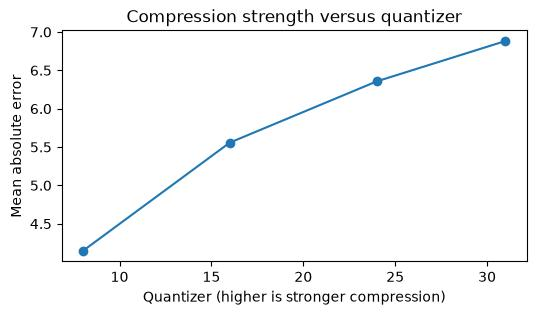

In [7]:
def mean_absolute_error(a: np.ndarray, b: np.ndarray) -> float:
    """Compute mean absolute pixel error between two frames."""
    return float(np.mean(np.abs(a.astype(np.float32) - b.astype(np.float32))))


quantizers = [8, 16, 24, 31]
mean_mae_by_quantizer = []

for quantizer in quantizers:
    perturber = CodecMacroblockPerturber(bit_rate=256_000, quantizer=quantizer, frame_rate=30.0)
    frames = list(perturber(frames=iter(video_frames)))
    mean_mae = np.mean(
        [
            mean_absolute_error(original.image, perturbed.image)
            for original, perturbed in zip(video_frames, frames, strict=True)
        ],
    )
    mean_mae_by_quantizer.append(float(mean_mae))
    print(f"q={quantizer:>2}: mean absolute error = {mean_mae:.4f}")

plt.figure(figsize=(6, 3))
plt.plot(quantizers, mean_mae_by_quantizer, marker="o")
plt.title("Compression strength versus quantizer")
plt.xlabel("Quantizer (higher is stronger compression)")
plt.ylabel("Mean absolute error")
plt.show()

## Packet Loss

The perturber can also drop packets from the encoded stream. In the default mode, `packet_loss_rate` drops encoded codec packets before muxing. Since a dropped codec packet may remove most or all of a decoded frame, this mode often shows up as dropped or black-filled frames rather than localized visual artifacts.

Here we preserve key packets with `packet_loss_preserve_keyframes=True`, then use `frame_count_policy="black"` so any missing decoded positions are filled with black frames and the output stays aligned with the input. `packet_loss_preserve_keyframes` defaults to `True`. We set it explicitly here for clarity, but you can omit it for the same behavior.

For independent loss, `packet_loss_burst_length` can drop fixed-length bursts. For burstier channel behavior, `packet_loss_model="gilbert_elliott"` switches to a two-state good/bad loss process.

In [8]:
packet_loss_perturber = CodecMacroblockPerturber(
    bit_rate=256_000,
    quantizer=16,
    frame_rate=30.0,
    gop_size=12,
    packet_loss_rate=0.1,
    packet_loss_seed=1,
    packet_loss_preserve_keyframes=True,
    frame_count_policy="black",
)

packet_loss_frames = list(packet_loss_perturber(frames=iter(video_frames)))
packet_loss_mae = np.mean(
    [
        mean_absolute_error(original.image, perturbed.image)
        for original, perturbed in zip(video_frames, packet_loss_frames, strict=True)
    ],
)
black_filled_count = sum(bool(np.all(frame.image == 0)) for frame in packet_loss_frames)

print(f"Packet-loss mean absolute error = {packet_loss_mae:.4f}")
print(f"Black-filled frame count = {black_filled_count}")

video_comparison(
    frame_sequences=[original_frame_sequence, [frame.image for frame in packet_loss_frames]],
    titles=["Original", "Compressed packet loss"],
    interval=dt_ms,
)

Packet-loss mean absolute error = 12.7085
Black-filled frame count = 8


## Unrecoverable Packet Loss

Packet loss can be configured aggressively enough that the compressed stream is no longer decodable. Here, every compressed packet is dropped and keyframes are not protected. PyAV then rejects the damaged stream before producing any decoded frames or frame positions.

Use extreme packet-loss settings with care. If PyAV rejects the stream before any frames are decoded, an error will be thrown.

In [9]:
unrecoverable_perturber = CodecMacroblockPerturber(
    bit_rate=256_000,
    quantizer=16,
    frame_rate=30.0,
    gop_size=12,
    packet_loss_mode="compressed_packet",
    packet_loss_rate=1.0,
    packet_loss_preserve_keyframes=False,
    frame_count_policy="black",
)

try:
    _ = list(unrecoverable_perturber(frames=iter(video_frames)))
except RuntimeError as error:
    print(f"Caught {type(error).__name__}: {error}")
    if error.__cause__ is not None:
        print(f"Caused by {type(error.__cause__).__name__}: {error.__cause__}")

Caught RuntimeError: The encoded or damaged video stream could not be decoded.
Caused by InvalidDataError: [Errno 1094995529] Invalid data found when processing input: '<none>'


## Transport Stream Packet Loss

Transport-stream mode is closer to a packetized transmission case. With `packet_loss_mode="transport_stream"`, the perturber muxes through MPEG-TS, drops 188-byte transport packets, and lets the decoder handle the damaged stream.

MPEG-TS table packets are preserved automatically. This example also uses `transport_loss_preserve_payload_starts=True` to keep packets that start payload units. `transport_loss_preserve_payload_starts` defaults to `True`. We set it explicitly here for clarity, but you can omit it for the same behavior. With payload starts preserved, the decoder usually has enough structure to produce damaged frames, so this mode tends to show visible artifacts more often than complete frame drops. The same independent and Gilbert-Elliott packet-loss models can be used here.

In [10]:
transport_loss_perturber = CodecMacroblockPerturber(
    bit_rate=256_000,
    quantizer=16,
    frame_rate=30.0,
    gop_size=12,
    packet_loss_mode="transport_stream",
    packet_loss_rate=0.1,
    packet_loss_seed=1,
    transport_loss_preserve_payload_starts=True,
    frame_count_policy="black",
)

transport_loss_frames = list(transport_loss_perturber(frames=iter(video_frames)))
transport_loss_mae = np.mean(
    [
        mean_absolute_error(original.image, perturbed.image)
        for original, perturbed in zip(video_frames, transport_loss_frames, strict=True)
    ],
)
transport_black_filled_count = sum(bool(np.all(frame.image == 0)) for frame in transport_loss_frames)

print(f"Transport-stream packet-loss mean absolute error = {transport_loss_mae:.4f}")
print(f"Black-filled frame count = {transport_black_filled_count}")

video_comparison(
    frame_sequences=[original_frame_sequence, [frame.image for frame in transport_loss_frames]],
    titles=["Original", "Transport stream packet loss"],
    interval=dt_ms,
)

Transport-stream packet-loss mean absolute error = 14.3214
Black-filled frame count = 0
